# Time-Series Models on Indian-Market Data

A guided tour of the `time_series_library` library: **ARMA** (conditional mean),
**GARCH** (conditional volatility) and **VAR** (multivariate dynamics &
impulse responses), applied to a bundled synthetic NSE dataset.

> The dataset ships with the package so the notebook runs fully offline. To use
> live data instead, install the extra (`uv sync --extra live`) and call
> `data.download_nse([...])`.

See the `tutorials/` folder for the mathematical background of each model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import time_series_library as tsi
from time_series_library import ARMA, GARCH, VAR, utils
from tests import data  # sample dataset for testing

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
print("time_series_library version:", tsi.__version__)

time_series_library version: 0.1.0


## 1. Load and explore the data

In [2]:
prices = data.load_nse_prices()
print(prices.shape)
prices.tail()

(1565, 5)


,NIFTY50,RELIANCE,TCS,HDFCBANK,INFY
Date,,,,,
2023-12-25,31621.26,1344.99,5831.71,2157.63,1350.54
2023-12-26,30928.05,1364.80,5868.67,2149.96,1341.24
2023-12-27,31330.49,1387.35,5868.38,2155.75,1341.11
2023-12-28,31290.62,1349.43,5922.10,2132.13,1359.61
2023-12-29,31446.25,1326.33,6121.38,2102.90,1361.03


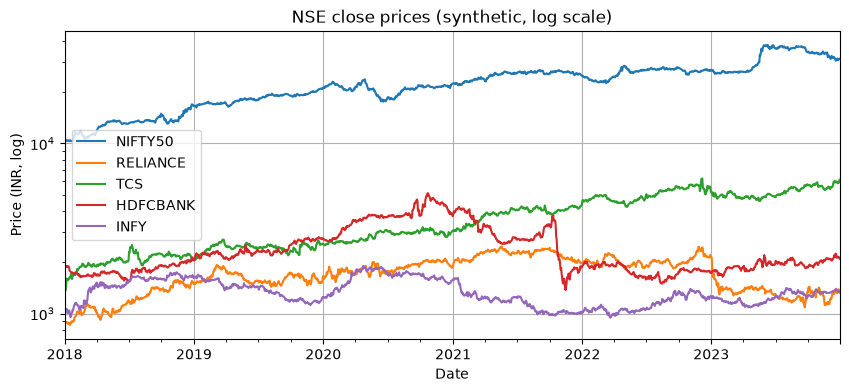

In [3]:
ax = prices.plot(logy=True, title="NSE close prices (synthetic, log scale)")
ax.set_ylabel("Price (INR, log)")
plt.show()

In [4]:
# Work with daily log-returns (stationary), in percent for readability.
returns = np.log(prices).diff().dropna() * 100
returns.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
NIFTY50,0.069818,1.100426,-6.464418,10.598788
RELIANCE,0.024377,1.892099,-16.641555,8.901735
TCS,0.095805,1.504737,-11.745934,13.372121
HDFCBANK,0.005109,1.855051,-15.429662,8.986408
INFY,0.016722,1.484401,-5.799477,10.216001


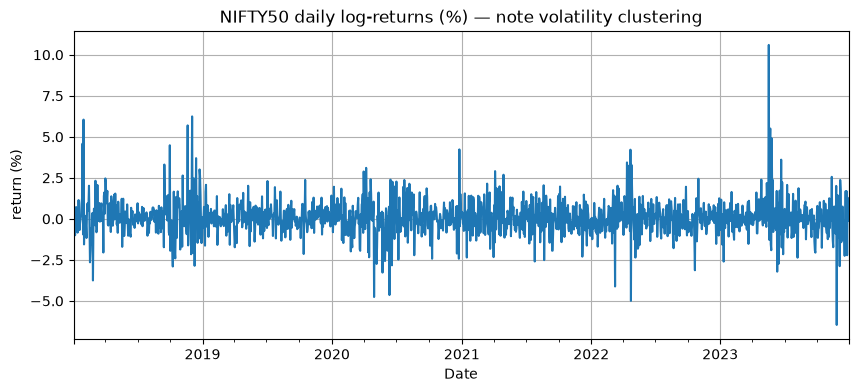

In [5]:
# Volatility clustering is visible in the NIFTY return series.
returns["NIFTY50"].plot(title="NIFTY50 daily log-returns (%) — note volatility clustering")
plt.ylabel("return (%)")
plt.show()

## 2. ARMA — the conditional mean

We inspect the ACF/PACF of NIFTY returns, fit a small ARMA, check residuals and
forecast.

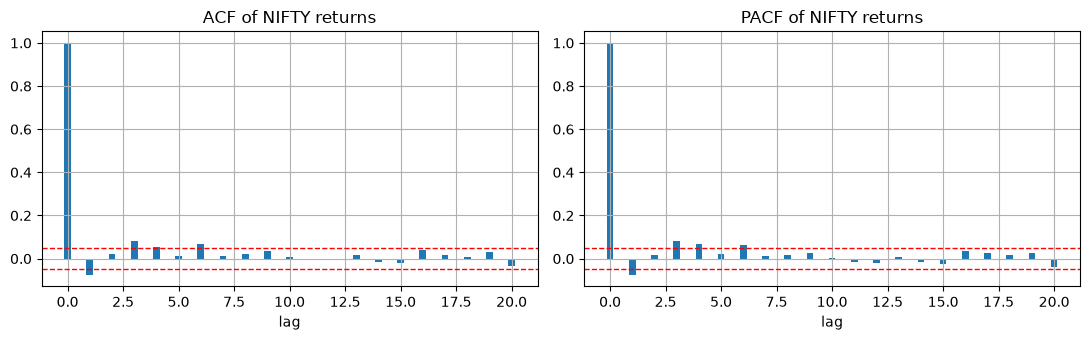

In [6]:
r = returns["NIFTY50"].to_numpy()
lags = 20
acf = utils.acf(r, lags)
pacf = utils.pacf(r, lags)
band = 1.96 / np.sqrt(len(r))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, vals, name in [(axes[0], acf, "ACF"), (axes[1], pacf, "PACF")]:
    ax.bar(range(lags + 1), vals, width=0.3)
    ax.axhline(band, color="r", ls="--", lw=1); ax.axhline(-band, color="r", ls="--", lw=1)
    ax.set_title(f"{name} of NIFTY returns"); ax.set_xlabel("lag")
plt.tight_layout(); plt.show()

In [7]:
# Compare a few orders by AIC/BIC.
rows = []
for p in range(3):
    for q in range(3):
        if p == 0 and q == 0:
            continue
        res = ARMA(p, q).fit(r)
        rows.append((f"ARMA({p},{q})", res.aic, res.bic))
pd.DataFrame(rows, columns=["model", "AIC", "BIC"]).sort_values("AIC").reset_index(drop=True)

/home/runner/work/time-series-analysis/time-series-analysis/src/time_series_library/arma.py:102: RuntimeWarning: overflow encountered in square
  sigma2 = np.mean(e**2)


,model,AIC,BIC
0,"ARMA(2,2)",4714.000243,4746.122577
1,"ARMA(1,2)",4715.307699,4742.079511
2,"ARMA(2,1)",4716.241762,4743.010374
3,"ARMA(2,0)",4731.039276,4752.454165
4,"ARMA(1,0)",4731.679732,4747.742819
5,"ARMA(1,1)",4733.530886,4754.948335
6,"ARMA(0,1)",4734.311123,4750.376128
7,"ARMA(0,2)",4734.387345,4755.807353


In [8]:
arma = ARMA(p=1, q=1)
res = arma.fit(r)
print(res.summary())

ARMA(1,1) — conditional MLE
nobs=1563  loglik=-2362.765  AIC=4733.53  BIC=4754.95
mu (const)     0.070018
ar.L1         -0.150286
ma.L1          0.074781
sigma2         1.203814


In [9]:
# Residual diagnostics: Ljung-Box should show no remaining autocorrelation.
lb = utils.ljung_box(res.resid, lags=10, dof=res.p + res.q)
print(lb)

LjungBoxResult(
  lag   1: Q=     0.001  p=0.9715
  lag   2: Q=     0.527  p=0.4678
  lag   3: Q=    12.592  p=0.0004
  lag   4: Q=    18.492  p=0.0001
  lag   5: Q=    19.333  p=0.0002
  lag   6: Q=    27.230  p=0.0000
  lag   7: Q=    27.693  p=0.0000
  lag   8: Q=    28.763  p=0.0001
  lag   9: Q=    30.964  p=0.0001
  lag  10: Q=    31.187  p=0.0001
)


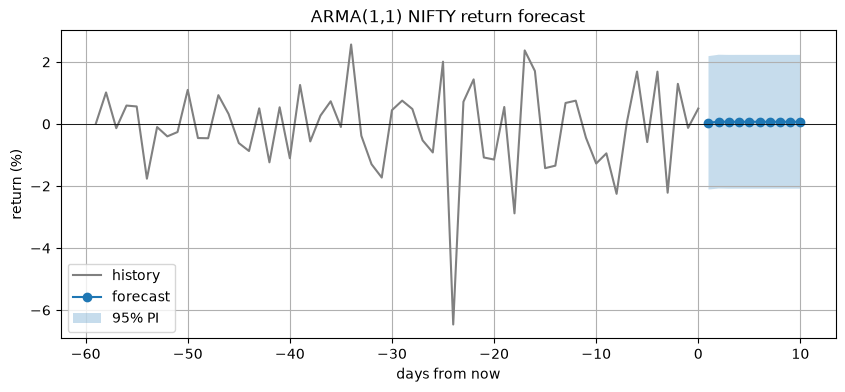

In [10]:
# Forecast the next 10 trading days with 95% prediction intervals.
fc = arma.forecast(h=10, alpha=0.05)
h = np.arange(1, 11)
hist = r[-60:]
plt.plot(np.arange(-len(hist) + 1, 1), hist, label="history", color="0.5")
plt.plot(h, fc["mean"], "o-", label="forecast")
plt.fill_between(h, fc["lower"], fc["upper"], alpha=0.25, label="95% PI")
plt.axhline(0, color="k", lw=0.6); plt.legend(); plt.title("ARMA(1,1) NIFTY return forecast")
plt.xlabel("days from now"); plt.ylabel("return (%)"); plt.show()

## 3. GARCH — time-varying volatility

Equity returns are close to white noise in the mean but show strong structure in
the **squared** returns. We fit a GARCH(1,1) and extract the volatility path.

In [11]:
r_rel = returns["RELIANCE"].to_numpy()

# ARCH effects: squared returns are autocorrelated.
lb2 = utils.ljung_box(r_rel**2, lags=10)
print("Ljung-Box on squared returns (expect tiny p-values):")
print(lb2)

Ljung-Box on squared returns (expect tiny p-values):
LjungBoxResult(
  lag   1: Q=    88.148  p=0.0000
  lag   2: Q=   100.899  p=0.0000
  lag   3: Q=   117.993  p=0.0000
  lag   4: Q=   181.574  p=0.0000
  lag   5: Q=   186.313  p=0.0000
  lag   6: Q=   191.097  p=0.0000
  lag   7: Q=   192.491  p=0.0000
  lag   8: Q=   211.432  p=0.0000
  lag   9: Q=   224.045  p=0.0000
  lag  10: Q=   228.568  p=0.0000
)


In [12]:
g = GARCH(p=1, q=1)
gres = g.fit(r_rel)
print(gres.summary())

GARCH(1,1) — Gaussian MLE
nobs=1564  loglik=-3085.515  AIC=6179.03  BIC=6200.45
persistence=0.9709  uncond.vol=1.939094
mu           0.032898
omega        0.10932760
alpha[1]     0.081862
beta[1]      0.889062


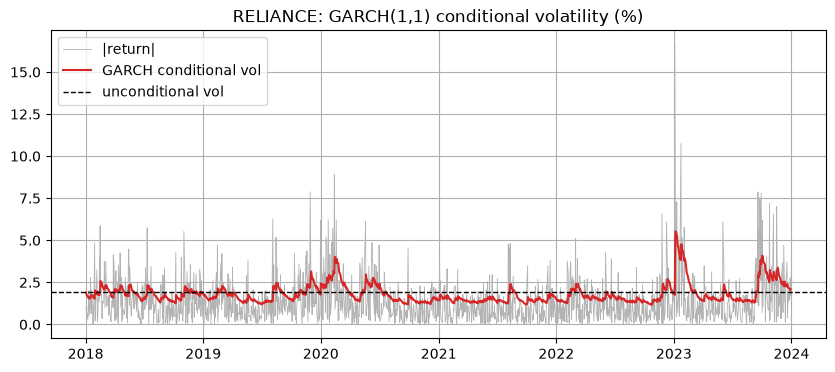

In [13]:
# Conditional volatility vs |returns|.
cv = pd.Series(gres.conditional_vol, index=returns.index)
fig, ax = plt.subplots()
ax.plot(returns.index, np.abs(r_rel), color="0.7", lw=0.6, label="|return|")
ax.plot(cv.index, cv.values, color="C3", label="GARCH conditional vol")
ax.axhline(gres.unconditional_vol, color="k", ls="--", lw=1, label="unconditional vol")
ax.set_title("RELIANCE: GARCH(1,1) conditional volatility (%)"); ax.legend(); plt.show()

In [14]:
# Standardised residuals should be ~white noise in level and square.
z = gres.resid / gres.conditional_vol
print("Ljung-Box on standardised squared residuals (expect large p-values):")
print(utils.ljung_box(z**2, lags=10))

Ljung-Box on standardised squared residuals (expect large p-values):
LjungBoxResult(
  lag   1: Q=     0.231  p=0.6308
  lag   2: Q=     0.235  p=0.8892
  lag   3: Q=     0.281  p=0.9636
  lag   4: Q=     0.849  p=0.9318
  lag   5: Q=     1.056  p=0.9580
  lag   6: Q=     1.066  p=0.9830
  lag   7: Q=     1.792  p=0.9705
  lag   8: Q=     1.905  p=0.9838
  lag   9: Q=     2.141  p=0.9890
  lag  10: Q=     2.180  p=0.9948
)


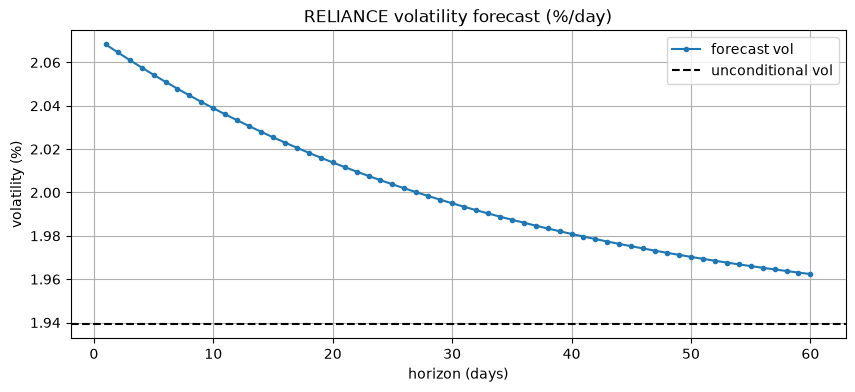

In [15]:
# Volatility term structure: forecasts mean-revert to the unconditional level.
vf = g.forecast(h=60)
plt.plot(range(1, 61), vf["volatility"], "o-", ms=3, label="forecast vol")
plt.axhline(gres.unconditional_vol, color="k", ls="--", label="unconditional vol")
plt.title("RELIANCE volatility forecast (%/day)"); plt.xlabel("horizon (days)")
plt.ylabel("volatility (%)"); plt.legend(); plt.show()

In [16]:
# One-day 99% Value-at-Risk from the GARCH one-step volatility.
from scipy import stats
sigma1 = vf["volatility"][0]
var99 = -(gres.mu + stats.norm.ppf(0.01) * sigma1)
print(f"1-day 99% VaR for RELIANCE ~ {var99:.2f}% of position value")

1-day 99% VaR for RELIANCE ~ 4.78% of position value


## 4. VAR — multivariate dynamics & impulse responses

We model the joint dynamics of the index and three stocks, then trace how a
shock to the NIFTY propagates through the system.

In [17]:
cols = ["NIFTY50", "RELIANCE", "TCS", "HDFCBANK"]
R = returns[cols]
var = VAR(p=2)
vres = var.fit(R)
print(vres.summary())

VAR(2) — OLS  [NIFTY50, RELIANCE, TCS, HDFCBANK]
nobs=1562  AIC=3.5285  BIC=3.6518  stable=True


In [18]:
fc = var.forecast(h=10)
fcast = pd.DataFrame(fc["mean"], columns=cols)
fcast.index = range(1, 11); fcast.index.name = "day"
fcast.round(3)

,NIFTY50,RELIANCE,TCS,HDFCBANK
day,,,,
1,0.054,0.182,0.269,-0.237
2,0.093,0.116,0.140,-0.245
3,0.080,0.002,0.076,-0.035
4,0.072,0.011,0.089,-0.013
5,0.070,0.024,0.097,0.001
6,0.070,0.026,0.097,0.004
7,0.070,0.026,0.096,0.005
8,0.070,0.026,0.096,0.006
9,0.070,0.026,0.096,0.006


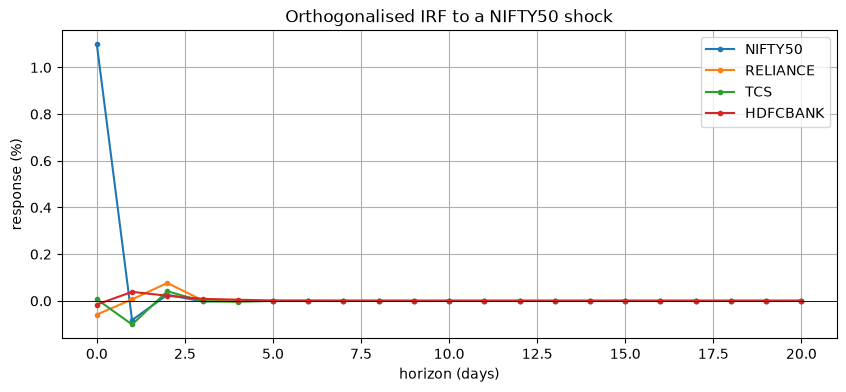

In [19]:
# Orthogonalised impulse responses to a NIFTY50 shock (ordered first).
H = 20
irf = var.impulse_response(h=H, orthogonalized=True)   # (H+1, k, k)
shock = 0  # NIFTY50
fig, ax = plt.subplots()
for i, name in enumerate(cols):
    ax.plot(range(H + 1), irf[:, i, shock], marker="o", ms=3, label=name)
ax.axhline(0, color="k", lw=0.6)
ax.set_title(f"Orthogonalised IRF to a {cols[shock]} shock")
ax.set_xlabel("horizon (days)"); ax.set_ylabel("response (%)"); ax.legend(); plt.show()

## 5. Summary

| Model | Captures | Key outputs |
|---|---|---|
| **ARMA** | conditional mean / autocorrelation | forecasts, prediction intervals |
| **GARCH** | conditional variance / vol clustering | volatility path, VaR, vol term structure |
| **VAR** | cross-asset dynamics | joint forecasts, impulse responses |

All three are estimated with NumPy/SciPy only and run on the bundled synthetic
NSE data — swap in live data via `data.download_nse(...)`. See `tutorials/` for
the underlying mathematics.